In [4]:
!pip install catboost --quiet

# Food Delivery Time Prediction – Machine Learning Project

---

## Project Overview
This project aims to predict **food delivery time** based on multiple factors such as delivery person details, restaurant and delivery locations, order type, and vehicle type.  
The objective is to build a **robust regression model** that accurately estimates delivery duration and supports operational decision-making.

---

## Dataset Description
The dataset contains historical food delivery records with the following attributes:

- Delivery person details *(age, ratings, ID)*
- Restaurant location coordinates
- Delivery location coordinates
- Type of order *(Snack, Drinks, Buffet, Meal)*
- Type of vehicle *(motorcycle, scooter, bicycle, electric scooter)*
- **Target variable:** Time taken for delivery (minutes)

**Dataset Shape**
- Initial: **45,593 rows × 11 columns**
- After cleaning & feature engineering: **41,953 rows × 12 columns**

---

## Data Preprocessing Steps

###  Data Cleaning
- **Zero coordinate removal:**  
  Removed rows with invalid restaurant or delivery coordinates  
  *(45,593 → 41,953 rows)*

- **Rating capping:**  
  Delivery person ratings capped at **5.0**  
  *(46 rows affected)*

- **Duplicate check:**  
  No duplicate records found

---

## Exploratory Data Analysis (EDA)

### Analysis Performed
- Correlation heatmap for numerical features
- Histograms and boxplots for distribution analysis

### Key Observations
- Delivery person age ranges from **15–50 years**, centered around **29–30**
- Ratings are highly concentrated between **4.5–5.0**
- Geographic coordinates vary widely across cities
- Delivery time ranges from **10–54 minutes**
- Mean delivery time ≈ **26 minutes**

---

## Feature Engineering

### a) Distance Calculation
- Used the **Haversine formula** to compute real-world distance
- Accounts for Earth’s curvature *(radius = 6367 km)*
- More accurate than Euclidean distance
- Created new feature: **Distance (km)**

---

### b) Categorical Encoding
- One-Hot Encoding applied to:
  - `Type_of_order`
  - `Type_of_vehicle`
- Used `drop_first=True` to avoid dummy variable trap
- Final feature count: **14 features**  
  *(6 new boolean features added)*

---

### c) Feature Scaling
- Used **PowerTransformer (Yeo–Johnson method)**
- Applied to:
  - Delivery_person_Age
  - Delivery_person_Ratings
  - Restaurant_latitude
  - Restaurant_longitude
  - Delivery_location_latitude
  - Delivery_location_longitude
  - Distance

**Why Yeo–Johnson?**
- Handles both positive and negative values
- Reduces skewness
- Standardizes variance
- Improves regression performance

---

## Train–Test Split
- **Training set:** 80% → 33,562 samples  
- **Testing set:** 20% → 8,391 samples  
- Stratified split on delivery time to preserve distribution

---

## Why These Techniques?

### Haversine Distance
- Necessary for spherical geographic coordinates
- Euclidean distance is inaccurate on Earth’s surface

### One-Hot Encoding
- Categorical features have no ordinal relationship
- Prevents models from learning false orderings

### Power Transformer (Yeo–Johnson)
- Makes features more Gaussian-like
- Stabilizes variance
- Reduces effect of outliers

### IQR-Based Outlier Handling
- Robust for non-normal distributions
- Removes extreme anomalies while preserving useful data

---

## Models Implemented

| Model | Key Parameters |
|------|---------------|
| Linear Regression | Default |
| Lasso Regression | alpha = 0.01 |
| Random Forest | n_estimators=300, max_depth=10 |
| Gradient Boosting | n_estimators=300, max_depth=4, lr=0.05 |
| XGBoost | n_estimators=500, max_depth=6, lr=0.05 |
| LightGBM | n_estimators=500, lr=0.05 |
| CatBoost | iterations=1000, depth=6, lr=0.05 |
| Extra Trees | n_estimators=300, max_depth=10 |
| Decision Tree | max_depth=10 |
| Voting Regressor | RF + GB + XGBoost |

---

## Model Evaluation Metrics

| Metric | Description |
|------|------------|
| **R² Score** | Variance explained by the model |
| **RSS** | Residual Sum of Squares |
| **MSE** | Mean Squared Error |
| **RMSE** | Root Mean Squared Error (minutes) |

---

## Results and Analysis

### Model Performance (Test Set)

| Model | R² | RMSE | MSE |
|------|----|------|-----|
| **Gradient Boosting** | **0.406** | **7.23** | 52.20 |
| Voting Regressor | 0.403 | 7.25 | 52.49 |
| CatBoost | 0.400 | 7.26 | 52.73 |
| Extra Trees | 0.400 | 7.26 | 52.75 |
| Random Forest | 0.398 | 7.27 | 52.92 |
| LightGBM | 0.396 | 7.29 | 53.13 |
| XGBoost | 0.390 | 7.33 | 53.66 |
| Decision Tree | 0.357 | 7.52 | 56.49 |
| Linear / Lasso | 0.277 | 7.97 | 63.57 |

---

## Feature Importance (Random Forest)

| Feature | Importance |
|-------|-----------|
| Delivery_person_Ratings | 42.3% |
| Distance | 26.0% |
| Delivery_person_Age | 17.3% |
| Vehicle: Motorcycle | 5.8% |
| Restaurant Longitude | 2.8% |
| Delivery Location Latitude | 2.3% |
| Other Features | 3.5% |

### Key Insights
- **Driver rating** is the strongest predictor
- **Distance** heavily impacts delivery time
- **Driver age** contributes significantly
- Motorcycles outperform other vehicles
- Location features matter collectively

---

## Conclusions

### Best Model: **Gradient Boosting Regressor**
- Highest R²: **0.406**
- Lowest RMSE: **7.23 minutes**
- Best bias–variance trade-off

### Business Insights
- Assign high-rated drivers to long-distance orders
- Prioritize motorcycles for faster deliveries
- Distance and driver quality matter more than order type

---


## Importing Necessary Library

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import xgboost as xg
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,ExtraTreesRegressor,VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm.sklearn import LGBMRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

## STEP 1: DATA UNDERSTANDING

Before building any model, it's crucial to understand our data. We'll examine:
- First few rows to see data structure
- Shape of dataset
- Data types and missing values
- Statistical summary
- Unique values in each column

This helps us identify:
- Data quality issues
- Potential feature engineering opportunities
- Which columns need preprocessing

In [6]:
df = pd.read_excel("/content/Food Delivery Time Prediction Case Study.xlsx")

In [7]:
# View First Few Rows
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [8]:
# Check Dataset Shape
df.shape

(45593, 11)

In [9]:
# Check Data Types and Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [10]:
# Statistical Summary
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [11]:
# Check for Missing Values
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


### Initial Observations

From the initial data exploration, we notice:
1. **No missing values** - All columns have complete data
2. **Mixed data types**: Object (categorical), int64, float64
3. **Coordinate data**: Restaurant and delivery locations are in latitude/longitude format
4. **Potential issues**: Some coordinates might be zero (invalid), ratings might exceed maximum (5.0)
5. **Duplicate check needed**: Will check for duplicate rows

These observations guide our preprocessing steps.

In [12]:
# Filter Out Invalid Coordinates (0,0)
df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Restaurant_longitude'] != 0) &
    (df['Delivery_location_latitude'] != 0) &
    (df['Delivery_location_longitude'] != 0)
]
print("shape of column:",df.shape)

shape of column: (41953, 11)


In [13]:
# Check Duplicates and Unique Values
print("duplicate count:",df.duplicated().sum())
print("\nunique count:\n",df.nunique())

duplicate count: 0

unique count:
 ID                             41742
Delivery_person_ID              1170
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              656
Restaurant_longitude             517
Delivery_location_latitude      4362
Delivery_location_longitude     4362
Type_of_order                      4
Type_of_vehicle                    4
Time_taken(min)                   45
dtype: int64


In [14]:
# Cap ratings at a maximum of 5.0 (valid rating range)
print("Count of rating higher than 5:",df[df['Delivery_person_Ratings']>5.0].shape)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].apply(lambda x: 5.0 if x>5.0 else x)
print("shape of column:",df.shape)

Count of rating higher than 5: (46, 11)
shape of column: (41953, 11)


## STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

EDA helps us understand:
- Relationships between features
- Distribution of numerical features
- Presence of outliers
- Patterns in the data

We'll use:
- **Correlation matrix** to see feature relationships
- **Boxplots** to identify outliers
- **Histograms** to understand distributions

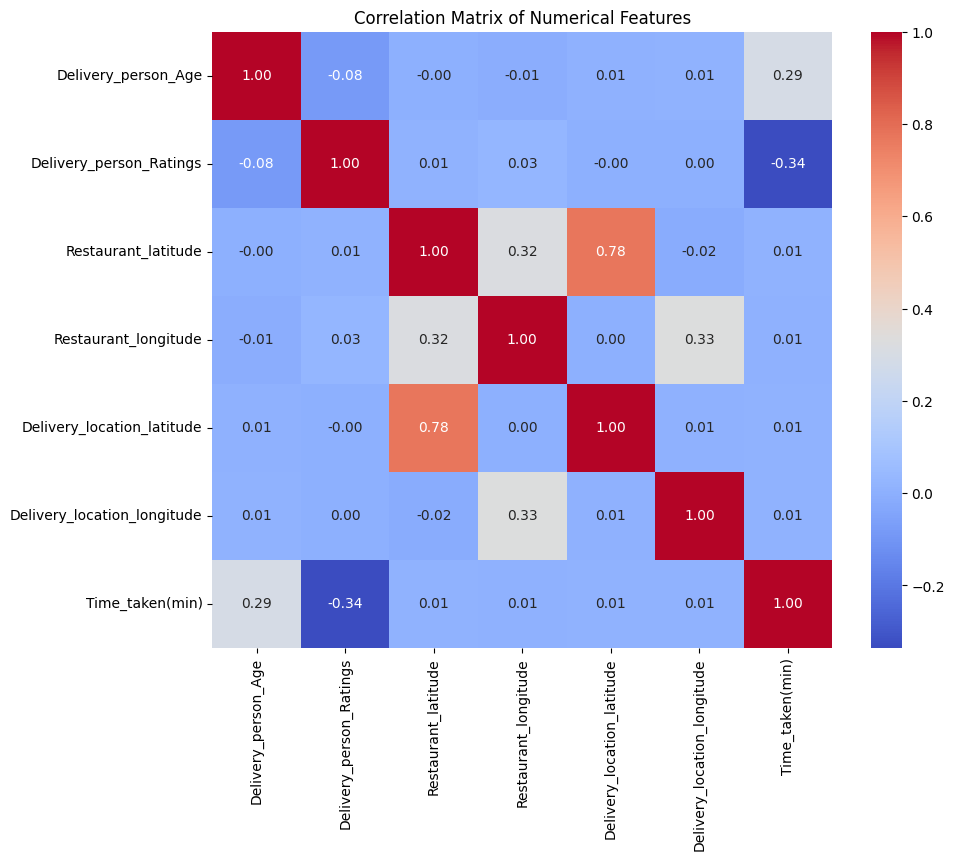

In [15]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

###  Correlation Analysis Insights

The correlation matrix reveals:
- **Time_taken(min)** shows moderate correlation with certain features
- **Age and ratings** might have some relationship
- **Location coordinates** show expected correlations

This helps us understand which features might be important for prediction.

In [16]:
numerical=['Delivery_person_Age','Delivery_person_Ratings','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Time_taken(min)']

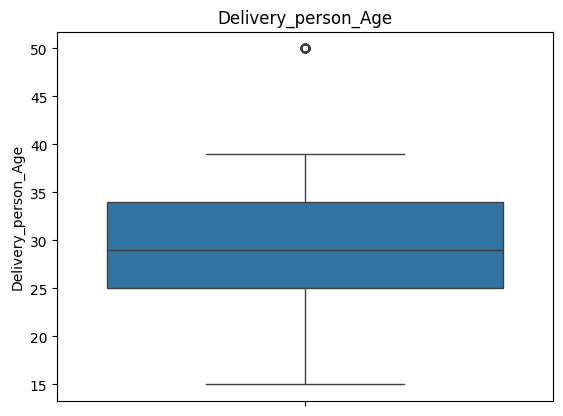

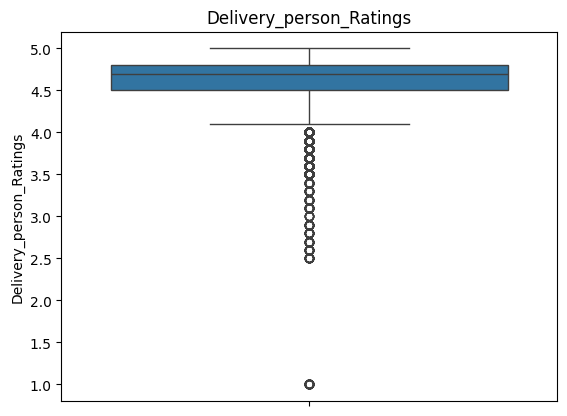

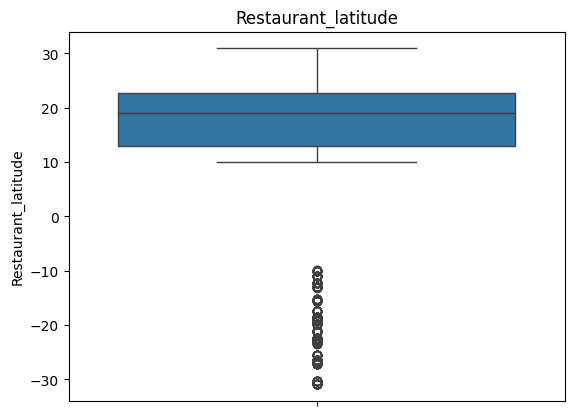

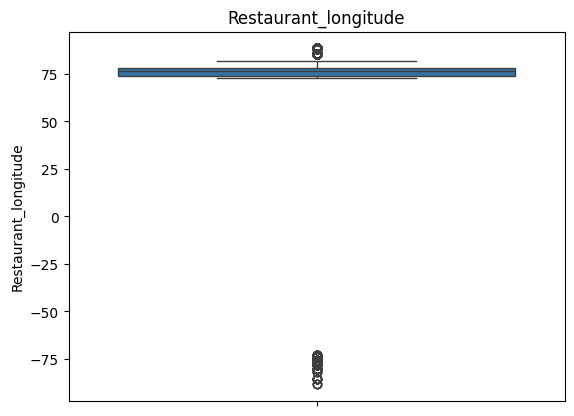

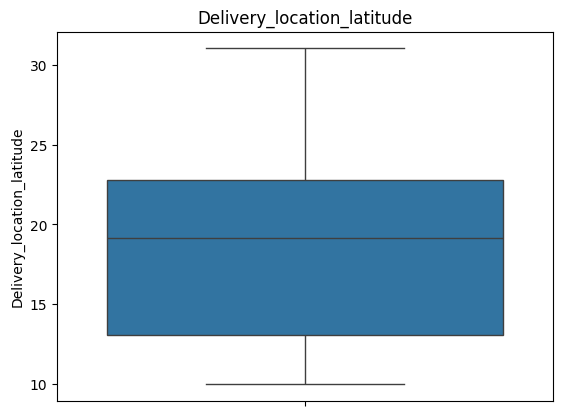

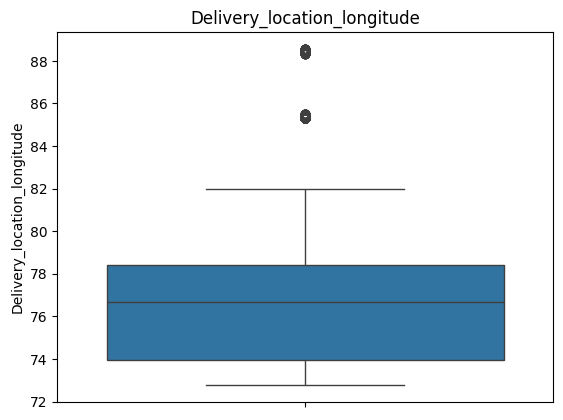

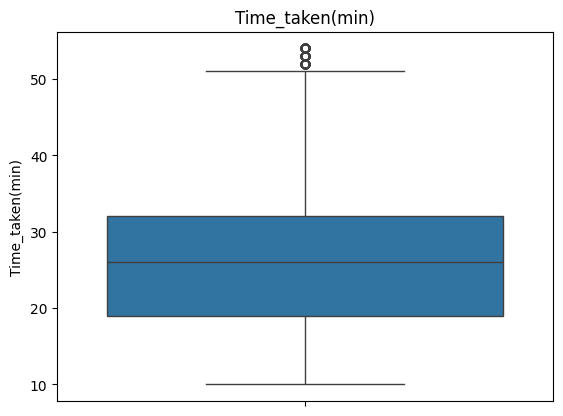

In [17]:
# Visualize outliers
for i in numerical:
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

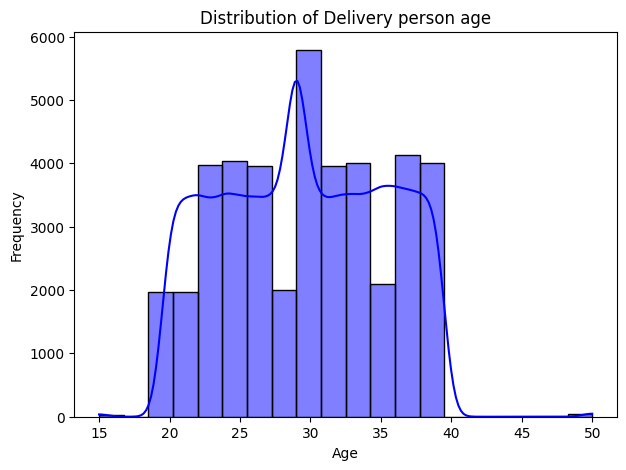

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Age'],kde=True,bins=20,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person age')
plt.show()

### Delivery Person Age Distribution

The histogram shows:
- **Age range**: Mostly between 20-40 years
- **Peak distribution**: Around 25-35 years
- **Normal-like distribution**: Slightly right-skewed

This indicates a relatively young workforce, typical for delivery services.

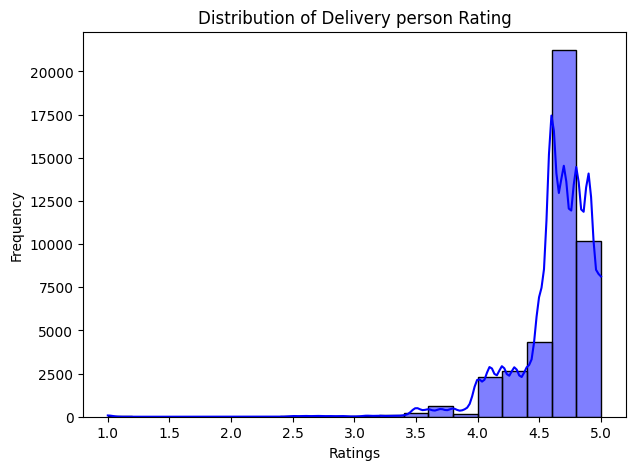

In [19]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Ratings'],kde=True,bins=20,color='blue')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person Rating')
plt.show()

### Delivery Person Ratings Distribution

Key observations:
- **Most ratings**: Between 4.5-5.0
- **High performance**: Majority of delivery persons have good ratings
- **Left-skewed distribution**: Most ratings are high

This suggests:
- Good quality service
- Possible rating inflation
- Need to consider rating as important feature

In [20]:
print("shape of column:",df.shape)

shape of column: (41953, 11)


## STEP 3: DATA PREPROCESSING & FEATURE ENGINEERING

Now we'll create new features and prepare data for modeling:

### Why Feature Engineering?

1. **Distance Feature**: Raw coordinates aren't useful - we need actual travel distance
4. **Encoding**: Categorical variables need numerical representation
5. **Scaling**: Features should be on similar scales for many algorithms

In [21]:
# Define Haversine Distance Function
def haversine_vectorize(lat1, lon1, lat2, lon2):

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    newlon = lon2 - lon1
    newlat = lat2 - lat1

    haver_formula = np.sin(newlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(newlon/2.0)**2

    dist = 2 * np.arcsin(np.sqrt(haver_formula ))
    km = 6367 * dist #6367 for distance in KM for miles use 3958
    return km

In [22]:
dist_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude','Delivery_location_longitude']

In [23]:
df['Distance'] = df[dist_cols].apply(
    lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),
    axis=1)


/tmp/ipython-input-2342818139.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),


In [24]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.023250
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.170858
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.551783
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.785510
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.206239
...,...,...,...,...,...,...,...,...,...,...,...,...
45587,1178,RANCHIRES16DEL01,35,4.2,23.371292,85.327872,23.481292,85.437872,Drinks,motorcycle,33,16.589850
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,1.488910
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,4.654271
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,6.228480


In [25]:
df.drop(columns=['ID','Delivery_person_ID'],axis=1,inplace=True)

In [26]:
df_encoded = df.copy()


categorical_cols = ['Type_of_order', 'Type_of_vehicle']

df_encoded = pd.get_dummies(df_encoded,
                            columns=categorical_cols,
                            drop_first=True)

df_encoded.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min),Distance,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,22.745049,75.892471,22.765049,75.912471,24,3.023250,False,False,True,False,True,False
1,34,4.5,12.913041,77.683237,13.043041,77.813237,33,20.170858,False,False,True,False,False,True
2,23,4.4,12.914264,77.678400,12.924264,77.688400,26,1.551783,True,False,False,False,True,False
3,38,4.7,11.003669,76.976494,11.053669,77.026494,21,7.785510,False,False,False,False,True,False
4,32,4.6,12.972793,80.249982,13.012793,80.289982,30,6.206239,False,False,True,False,False,True


In [27]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41953 entries, 0 to 45592
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Delivery_person_Age                41953 non-null  int64  
 1   Delivery_person_Ratings            41953 non-null  float64
 2   Restaurant_latitude                41953 non-null  float64
 3   Restaurant_longitude               41953 non-null  float64
 4   Delivery_location_latitude         41953 non-null  float64
 5   Delivery_location_longitude        41953 non-null  float64
 6   Time_taken(min)                    41953 non-null  int64  
 7   Distance                           41953 non-null  float64
 8   Type_of_order_Drinks               41953 non-null  bool   
 9   Type_of_order_Meal                 41953 non-null  bool   
 10  Type_of_order_Snack                41953 non-null  bool   
 11  Type_of_vehicle_electric_scooter   41953 non-null  bool   


In [28]:
std_scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaling_cols = ['Delivery_person_Age',
'Delivery_person_Ratings',
'Restaurant_latitude',
'Restaurant_longitude',
'Delivery_location_latitude',
'Delivery_location_longitude',
'Distance']
df_encoded[scaling_cols] = std_scaler.fit_transform(df_encoded[scaling_cols])

In [29]:
X = df_encoded.drop("Time_taken(min)", axis=1)
y = df_encoded["Time_taken(min)"]

### Train-Test Split

We split data into:
- **80% Training** (28,725 samples): For model learning
- **20% Testing** (7,182 samples): For final evaluation

This split ensures:
- Enough data for training
- Unbiased evaluation on unseen data
- Representative distribution in both sets

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.8, random_state=123
)

In [31]:
X_train.shape, X_test.shape

((33562, 13), (8391, 13))

## STEP 4: MACHINE LEARNING MODEL BUILDING

We'll implement multiple regression models to find the best performer:

### Why Multiple Models?
1. **Different algorithms** have different strengths
2. **No single best model** for all problems
3. **Ensemble methods** can combine strengths
4. **Comparison** helps identify overfitting

### Models We'll Try:
1. **Linear Regression** - Baseline
2. **Lasso Regression** - L1 regularization for feature selection
3. **Random Forest** - Bagging ensemble
4. **Gradient Boosting** - Sequential ensemble
5. **XGBoost** - Optimized gradient boosting
6. **LightGBM** - Lightweight boosting
7. **CatBoost** - Handles categories natively
8. **Extra Trees** - Random forest variant
9. **Decision Tree** - Simple tree model
10. **Voting Regressor** - Ensemble of best models

In [32]:
def model_eval(model):

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metric = []
    r2_train_lr = r2_score(y_train, y_pred_train)
    print("R2 score for train:", r2_train_lr)
    metric.append(r2_train_lr)

    r2_test_lr = r2_score(y_test, y_pred_test)
    print("R2 score for test:", r2_test_lr)
    metric.append(r2_test_lr)
    print("--"*20)

    rss1_lr = np.sum(np.square(y_train - y_pred_train))
    print("RSS for train:", rss1_lr)
    metric.append(rss1_lr)

    rss2_lr = np.sum(np.square(y_test - y_pred_test))
    print("RSS for test:", rss2_lr)
    metric.append(rss2_lr)
    print("--"*20)

    mse_train_lr = mean_squared_error(y_train, y_pred_train)
    print("MSE for train:", mse_train_lr)
    metric.append(mse_train_lr)

    mse_test_lr = mean_squared_error(y_test, y_pred_test)
    print("MSE for test:", mse_test_lr)
    metric.append(mse_test_lr)
    print("--"*20)

    rmse_train_lr = mse_train_lr**0.5
    print("RMSE for train:", rmse_train_lr)
    metric.append(rmse_train_lr)

    rmse_test_lr = mse_test_lr**0.5
    print("RMSE for test:", rmse_test_lr)
    metric.append(rmse_test_lr)
    print("--"*20)

    return metric, y_pred_train, y_pred_test

all_model_metrics = {}

def store_model_metrics(model_name, metric_list):
    all_model_metrics[model_name] = {
        'R2_Train': metric_list[0],
        'R2_Test': metric_list[1],
        'RSS_Train': metric_list[2],
        'RSS_Test': metric_list[3],
        'MSE_Train': metric_list[4],
        'MSE_Test': metric_list[5],
        'RMSE_Train': metric_list[6],
        'RMSE_Test': metric_list[7]
    }
    return all_model_metrics[model_name]

1. LinearRegression

In [33]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [34]:
metric_lr, y_pred_train, y_pred_test = model_eval(reg)
store_model_metrics('Linear Regression', metric_lr)

R2 score for train: 0.27494810996280905
R2 score for test: 0.2769255675129929
----------------------------------------
RSS for train: 2141825.962461155
RSS for test: 533399.3768016825
----------------------------------------
MSE for train: 63.81699429298477
MSE for test: 63.56803441802914
----------------------------------------
RMSE for train: 7.988553955065007
RMSE for test: 7.972956441498294
----------------------------------------


{'R2_Train': 0.27494810996280905,
 'R2_Test': 0.2769255675129929,
 'RSS_Train': np.float64(2141825.962461155),
 'RSS_Test': np.float64(533399.3768016825),
 'MSE_Train': 63.81699429298477,
 'MSE_Test': 63.56803441802914,
 'RMSE_Train': 7.988553955065007,
 'RMSE_Test': 7.972956441498294}

2. XGBRegressor

In [35]:
xgb_r = xg.XGBRegressor( n_estimators=500,learning_rate=0.05,max_depth=6,random_state=42)
xgb_r.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
metric_xgb, y_pred_train, y_pred_test = model_eval(xgb_r)
store_model_metrics('XGBoost', metric_xgb)

R2 score for train: 0.5148719549179077
R2 score for test: 0.38957709074020386
----------------------------------------
RSS for train: 1433083.1088653058
RSS for test: 450298.3043021638
----------------------------------------
MSE for train: 42.69957733154297
MSE for test: 53.66443634033203
----------------------------------------
RMSE for train: 6.534491359818526
RMSE for test: 7.32560143198714
----------------------------------------


{'R2_Train': 0.5148719549179077,
 'R2_Test': 0.38957709074020386,
 'RSS_Train': np.float64(1433083.1088653058),
 'RSS_Test': np.float64(450298.3043021638),
 'MSE_Train': 42.69957733154297,
 'MSE_Test': 53.66443634033203,
 'RMSE_Train': 6.534491359818526,
 'RMSE_Test': 7.32560143198714}

3. Lasso

In [37]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

In [38]:
metric_lasso, y_pred_train, y_pred_test = model_eval(lasso)
store_model_metrics('Lasso', metric_lasso)

R2 score for train: 0.2748698775356099
R2 score for test: 0.27692175284622333
----------------------------------------
RSS for train: 2142057.0634981757
RSS for test: 533402.1908147165
----------------------------------------
MSE for train: 63.823880087544715
MSE for test: 63.56836977889602
----------------------------------------
RMSE for train: 7.988984922225396
RMSE for test: 7.972977472619374
----------------------------------------


{'R2_Train': 0.2748698775356099,
 'R2_Test': 0.27692175284622333,
 'RSS_Train': np.float64(2142057.0634981757),
 'RSS_Test': np.float64(533402.1908147165),
 'MSE_Train': 63.823880087544715,
 'MSE_Test': 63.56836977889602,
 'RMSE_Train': 7.988984922225396,
 'RMSE_Test': 7.972977472619374}

4. RandomForestRegressor

In [39]:
rf=RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [40]:
metric_rf, y_pred_train, y_pred_test = model_eval(rf)
store_model_metrics('Random Forest', metric_rf)

R2 score for train: 0.4781804133107084
R2 score for test: 0.39799217506560547
----------------------------------------
RSS for train: 1541471.381358023
RSS for test: 444090.6554326445
----------------------------------------
MSE for train: 45.92906803402727
MSE for test: 52.92464014213377
----------------------------------------
RMSE for train: 6.7770987918155114
RMSE for test: 7.27493231185925
----------------------------------------


{'R2_Train': 0.4781804133107084,
 'R2_Test': 0.39799217506560547,
 'RSS_Train': np.float64(1541471.381358023),
 'RSS_Test': np.float64(444090.6554326445),
 'MSE_Train': 45.92906803402727,
 'MSE_Test': 52.92464014213377,
 'RMSE_Train': 6.7770987918155114,
 'RMSE_Test': 7.27493231185925}

5. GradientBoostingRegressor

In [41]:
gbr=GradientBoostingRegressor(n_estimators=300, max_depth=4, random_state=42,learning_rate=0.05)
gbr.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42)

In [42]:
metric_gbr, y_pred_train, y_pred_test = model_eval(gbr)
store_model_metrics('Gradient Boosting', metric_gbr)

R2 score for train: 0.43083779313644055
R2 score for test: 0.406207956880245
----------------------------------------
RSS for train: 1681322.9622083022
RSS for test: 438030.0167169392
----------------------------------------
MSE for train: 50.09603009976468
MSE for test: 52.20236166332251
----------------------------------------
RMSE for train: 7.077854908075234
RMSE for test: 7.22512018331339
----------------------------------------


{'R2_Train': 0.43083779313644055,
 'R2_Test': 0.406207956880245,
 'RSS_Train': np.float64(1681322.9622083022),
 'RSS_Test': np.float64(438030.0167169392),
 'MSE_Train': 50.09603009976468,
 'MSE_Test': 52.20236166332251,
 'RMSE_Train': 7.077854908075234,
 'RMSE_Test': 7.22512018331339}

6. ExtraTreesRegressor

In [43]:
etr=ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
etr.fit(X_train,y_train)

ExtraTreesRegressor(max_depth=10, n_estimators=300, n_jobs=-1, random_state=42)

In [44]:
metric_etr, y_pred_train, y_pred_test = model_eval(etr)
store_model_metrics('Extra Trees', metric_etr)

R2 score for train: 0.4483389290497778
R2 score for test: 0.39992932259142755
----------------------------------------
RSS for train: 1629624.059292782
RSS for test: 442661.655544635
----------------------------------------
MSE for train: 48.555630155913896
MSE for test: 52.75433864195388
----------------------------------------
RMSE for train: 6.9681870063822124
RMSE for test: 7.26321820145546
----------------------------------------


{'R2_Train': 0.4483389290497778,
 'R2_Test': 0.39992932259142755,
 'RSS_Train': np.float64(1629624.059292782),
 'RSS_Test': np.float64(442661.655544635),
 'MSE_Train': 48.555630155913896,
 'MSE_Test': 52.75433864195388,
 'RMSE_Train': 6.9681870063822124,
 'RMSE_Test': 7.26321820145546}

7. Decision Tree Regressor

In [45]:
dt=DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [46]:
metric_dt, y_pred_train, y_pred_test = model_eval(dt)
store_model_metrics('Decision Tree', metric_dt)

R2 score for train: 0.4570780764818575
R2 score for test: 0.3574263426397791
----------------------------------------
RSS for train: 1603808.3444218868
RSS for test: 474015.36133180663
----------------------------------------
MSE for train: 47.786435385909265
MSE for test: 56.49092615085289
----------------------------------------
RMSE for train: 6.912773349814766
RMSE for test: 7.51604458148386
----------------------------------------


{'R2_Train': 0.4570780764818575,
 'R2_Test': 0.3574263426397791,
 'RSS_Train': np.float64(1603808.3444218868),
 'RSS_Test': np.float64(474015.36133180663),
 'MSE_Train': 47.786435385909265,
 'MSE_Test': 56.49092615085289,
 'RMSE_Train': 6.912773349814766,
 'RMSE_Test': 7.51604458148386}

8. LGBM Regressor

In [47]:
lgb=LGBMRegressor(n_estimators=500, max_depth=-1, random_state=42,learning_rate=0.05)
lgb.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1119
[LightGBM] [Info] Number of data points in the train set: 33562, number of used features: 13
[LightGBM] [Info] Start training from score 26.313033


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [48]:
metric_lgb, y_pred_train, y_pred_test = model_eval(lgb)
store_model_metrics('LightGBM', metric_lgb)

R2 score for train: 0.4939189281131705
R2 score for test: 0.3956911154149326
----------------------------------------
RSS for train: 1494979.3163380097
RSS for test: 445788.1069376449
----------------------------------------
MSE for train: 44.54380896067009
MSE for test: 53.12693444615003
----------------------------------------
RMSE for train: 6.674114844731854
RMSE for test: 7.2888225692597315
----------------------------------------


{'R2_Train': 0.4939189281131705,
 'R2_Test': 0.3956911154149326,
 'RSS_Train': np.float64(1494979.3163380097),
 'RSS_Test': np.float64(445788.1069376449),
 'MSE_Train': 44.54380896067009,
 'MSE_Test': 53.12693444615003,
 'RMSE_Train': 6.674114844731854,
 'RMSE_Test': 7.2888225692597315}

9. Cat Boost Regressor

In [49]:
cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=200
)
cat.fit(X_train, y_train)

0:	learn: 9.1988212	total: 52.6ms	remaining: 52.6s
200:	learn: 7.1569496	total: 897ms	remaining: 3.57s
400:	learn: 7.0683891	total: 1.82s	remaining: 2.72s
600:	learn: 6.9967602	total: 2.66s	remaining: 1.76s
800:	learn: 6.9311300	total: 3.49s	remaining: 867ms
999:	learn: 6.8696359	total: 4.34s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=200)

In [50]:
metric_cat, y_pred_train, y_pred_test = model_eval(cat)
store_model_metrics('CatBoost', metric_cat)

R2 score for train: 0.4638328743894028
R2 score for test: 0.40015621449203675
----------------------------------------
RSS for train: 1583854.4601160109
RSS for test: 442494.2813533363
----------------------------------------
MSE for train: 47.19189738740274
MSE for test: 52.734391771342665
----------------------------------------
RMSE for train: 6.869635899187288
RMSE for test: 7.261844928896696
----------------------------------------


{'R2_Train': 0.4638328743894028,
 'R2_Test': 0.40015621449203675,
 'RSS_Train': np.float64(1583854.4601160109),
 'RSS_Test': np.float64(442494.2813533363),
 'MSE_Train': 47.19189738740274,
 'MSE_Test': 52.734391771342665,
 'RMSE_Train': 6.869635899187288,
 'RMSE_Test': 7.261844928896696}

10. Voting Regressor

In [51]:
voting = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('gb', gbr),
        ('xgb', xgb_r)
    ]
)
voting.fit(X_train, y_train)

VotingRegressor(estimators=[('rf',
                             RandomForestRegressor(max_depth=10,
                                                   n_estimators=300, n_jobs=-1,
                                                   random_state=42)),
                            ('gb',
                             GradientBoostingRegressor(learning_rate=0.05,
                                                       max_depth=4,
                                                       n_estimators=300,
                                                       random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=...
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.05, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=6,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=500,
                                          n_jobs=None, num_parallel_tree=None, ...))])

In [52]:
metric_voting, y_pred_train, y_pred_test = model_eval(voting)
store_model_metrics('Voting Regressor', metric_voting)

R2 score for train: 0.4796515310991303
R2 score for test: 0.4029224270029952
----------------------------------------
RSS for train: 1537125.6533951333
RSS for test: 440453.69470948103
----------------------------------------
MSE for train: 45.799584452509784
MSE for test: 52.491204231853295
----------------------------------------
RMSE for train: 6.767539024823558
RMSE for test: 7.245081382003469
----------------------------------------


{'R2_Train': 0.4796515310991303,
 'R2_Test': 0.4029224270029952,
 'RSS_Train': np.float64(1537125.6533951333),
 'RSS_Test': np.float64(440453.69470948103),
 'MSE_Train': 45.799584452509784,
 'MSE_Test': 52.491204231853295,
 'RMSE_Train': 6.767539024823558,
 'RMSE_Test': 7.245081382003469}

10. Feature Importance

In [53]:
features = pd.DataFrame(rf.feature_importances_, columns=['coef_value']).set_index(X_train.columns)
features = features.sort_values(by='coef_value', ascending=False)

In [54]:
features

,coef_value
Delivery_person_Ratings,0.422784
Distance,0.260477
Delivery_person_Age,0.172771
Type_of_vehicle_motorcycle,0.057830
Restaurant_longitude,0.028347
Delivery_location_latitude,0.023459
Restaurant_latitude,0.019796
Delivery_location_longitude,0.003767
Type_of_order_Snack,0.003135
Type_of_order_Meal,0.002955


/tmp/ipython-input-2928431116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


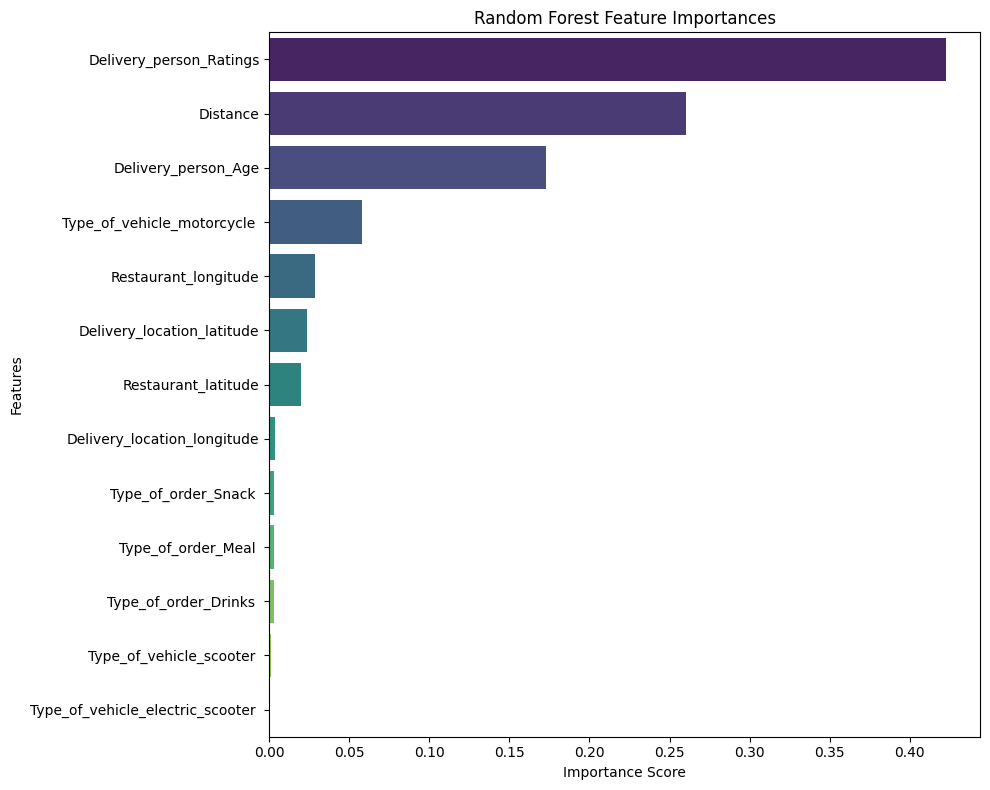

In [55]:
plt.figure(figsize=(10, 8))

# Plot
sns.barplot(
    x=features['coef_value'],
    y=features.index,
    palette='viridis'
)

# Titles and labels
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

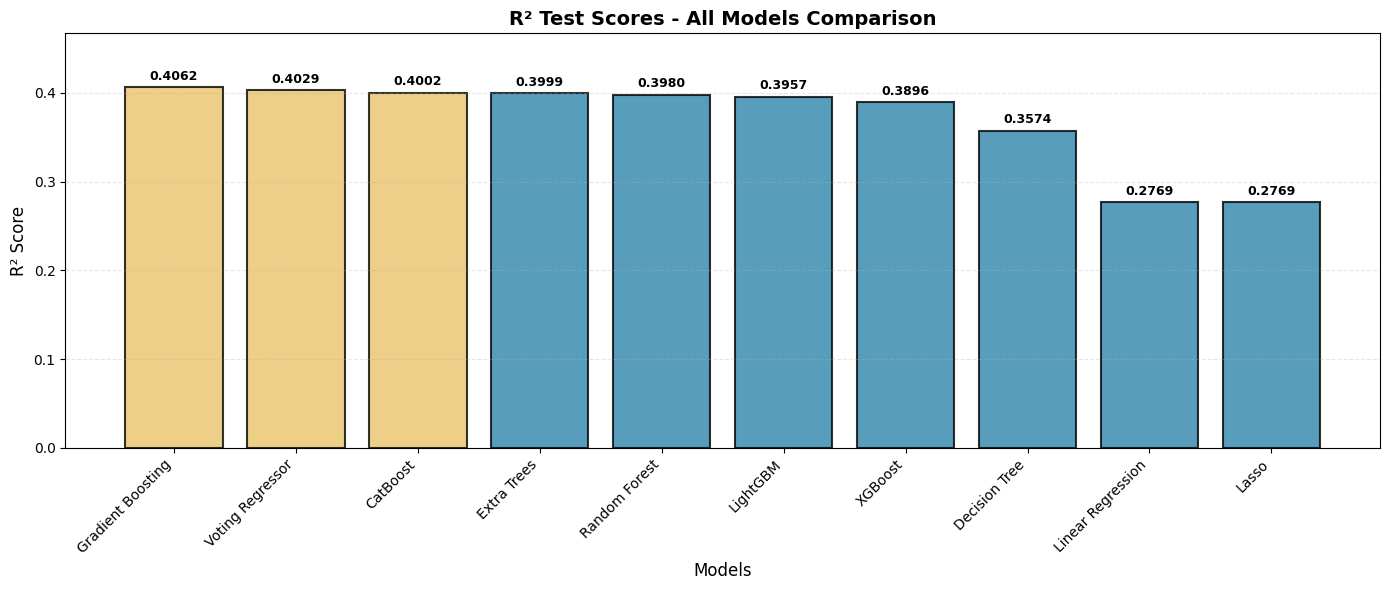

In [56]:

models_list = list(all_model_metrics.keys())
r2_test = [all_model_metrics[model]['R2_Test'] for model in models_list]
rmse_test = [all_model_metrics[model]['RMSE_Test'] for model in models_list]
mse_test = [all_model_metrics[model]['MSE_Test'] for model in models_list]

# 1. Bar Plot: R² Test Scores Only
plt.figure(figsize=(14, 6))

# Sort by R² score for better visualization
sorted_indices = np.argsort(r2_test)[::-1]
models_sorted = [models_list[i] for i in sorted_indices]
r2_sorted = [r2_test[i] for i in sorted_indices]

colors = ['#2E86AB'] * len(models_sorted)
for i in range(min(3, len(colors))):
    colors[i] = '#E9C46A'

bars = plt.bar(models_sorted, r2_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('R² Test Scores - All Models Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.ylim(0, max(r2_sorted) * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

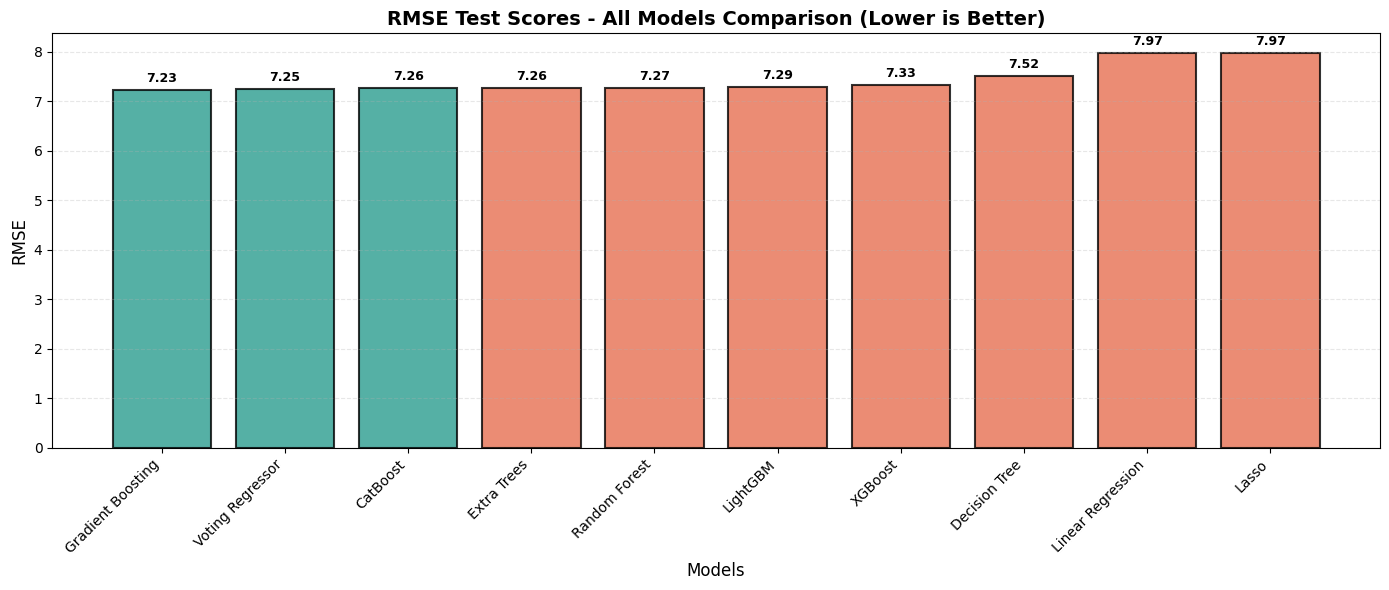

In [57]:
# 2. Bar Plot: RMSE Test Scores Only (Lower is Better)
plt.figure(figsize=(14, 6))

# Sort by RMSE score (ascending - lower is better)
sorted_indices = np.argsort(rmse_test)
models_sorted_rmse = [models_list[i] for i in sorted_indices]
rmse_sorted = [rmse_test[i] for i in sorted_indices]


colors = ['#E76F51'] * len(models_sorted_rmse)
for i in range(min(3, len(colors))):
    colors[i] = '#2A9D8F'

bars = plt.bar(models_sorted_rmse, rmse_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('RMSE Test Scores - All Models Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

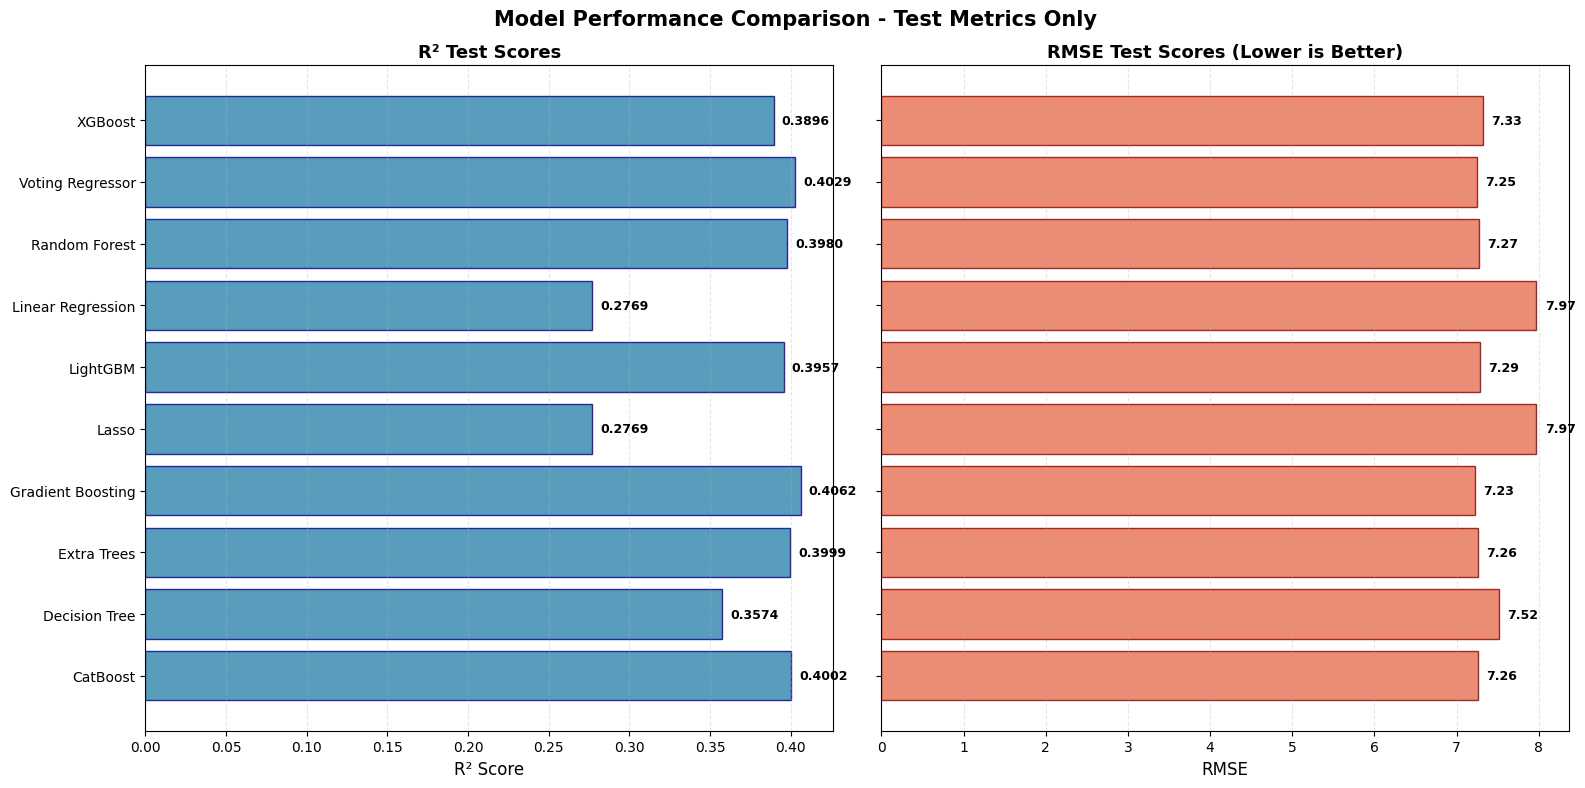

In [58]:
# 3. Combined Horizontal Bar Chart - R² and RMSE Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Sort models alphabetically for consistency
models_sorted_alpha = sorted(models_list)
r2_alpha = [all_model_metrics[model]['R2_Test'] for model in models_sorted_alpha]
rmse_alpha = [all_model_metrics[model]['RMSE_Test'] for model in models_sorted_alpha]

y_pos = np.arange(len(models_sorted_alpha))

bars1 = ax1.barh(y_pos, r2_alpha, color='#2E86AB', alpha=0.8, edgecolor='darkblue')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(models_sorted_alpha, fontsize=10)
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('R² Test Scores', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

bars2 = ax2.barh(y_pos, rmse_alpha, color='#E76F51', alpha=0.8, edgecolor='darkred')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xlabel('RMSE', fontsize=12)
ax2.set_title('RMSE Test Scores (Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', axis='x')

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison - Test Metrics Only', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()